In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv(
    "../outputs/cleaned_data/APL_Logistics_Cleaned.csv",
    encoding="latin1"
)
print("Dataset loaded successfully!")
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 42


In [4]:
	df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode,Delay_Gap,Delivery_performance
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,2,Delayed
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,167.96,48.71,Central America,CortÃ©s,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,0,On_Time
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,181.99,87.36,Central America,CortÃ©s,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class,0,On_Time
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class,2,Delayed
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,2,Delayed


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.980000,7.000000,31.520000,64.800000,911.800000
Sales per customer,180519.0,183.107607,120.043668,7.490000,104.380000,163.990000,247.400000,1939.990000
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [8]:
total_orders = len(df)
print("Total Orders:",total_orders)

Total Orders: 180519


In [9]:
avg_actual_days =df["Days for shipping (real)"].mean()
print("Average Actual Shipping Days:",
      round(avg_actual_days, 2))

Average Actual Shipping Days: 3.5


In [10]:
avg_scheduled_days = df["Days for shipment (scheduled)"].mean()
print("Average Scheduled Shipment Days:",
      round(avg_scheduled_days,2))

Average Scheduled Shipment Days: 2.93


In [11]:
avg_delay_gap =df["Delay_Gap"].mean()
print("Average Delay Gap:",
      round(avg_delay_gap,2))


Average Delay Gap: 0.57


In [15]:
performance_counts = df["Delivery_performance"].value_counts()
print(performance_counts)

Delayed    103400
Early       43366
On_Time     33753
Name: Delivery_performance, dtype: int64


In [14]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'Delay_Gap', 'Delivery_performance']


In [16]:
performance_percent =(
    df["Delivery_performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(performance_percent)

Delayed    57.28
Early      24.02
On_Time    18.70
Name: Delivery_performance, dtype: float64


In [17]:
late_risk_rate=(
    df["Late_delivery_risk"].mean()*100
)
print(
    "Late Delivery Risk Rate:",
    round(late_risk_rate,2),
    "%"
)

Late Delivery Risk Rate: 54.83 %


In [18]:
kpi_summary = pd.DataFrame({
    "KPI":[
        "Total Order",
        "Average Actual Shipping Days",
        "Average Scheduled Shipping Days",
        "Average Delay Gap",
        "Late Delivery Risk Rate"
				],
                "value":[
                    total_orders,
                    round(avg_actual_days,2),
                    round(avg_scheduled_days,2),
                    round(avg_delay_gap,2),
                    round(late_risk_rate,2)
																]
})
kpi_summary

,KPI,value
0,Total Order,180519.00
1,Average Actual Shipping Days,3.50
2,Average Scheduled Shipping Days,2.93
3,Average Delay Gap,0.57
4,Late Delivery Risk Rate,54.83


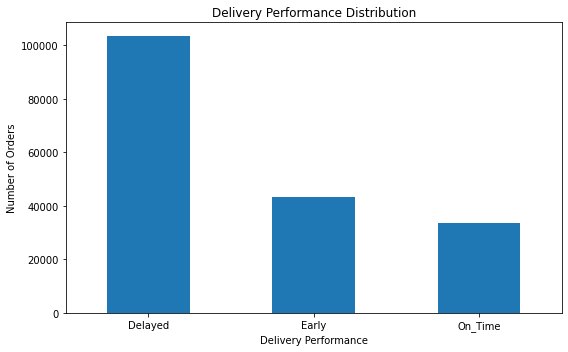

In [19]:
performance_counts = df["Delivery_performance"].value_counts()
plt.figure(figsize=(8,5))
performance_counts.plot(kind="bar")
plt.title("Delivery Performance Distribution")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

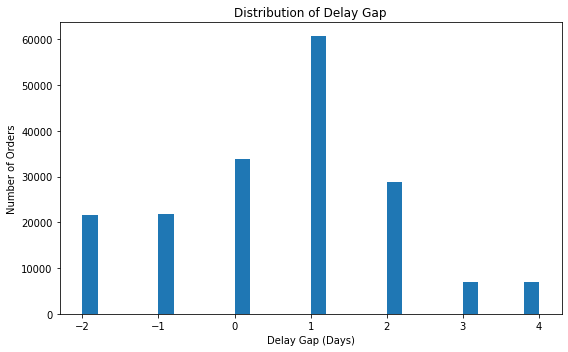

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df["Delay_Gap"],bins=30)
plt.title("Distribution of Delay Gap")
plt.xlabel("Delay Gap (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [21]:
shipping_analysis =(
    df.groupby("Shipping Mode")
    .agg(
        Orders=("Shipping Mode","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index()   
)
shipping_analysis["Late_Risk_Rate"] =(
    shipping_analysis["Late_Risk_Rate"]*100
)
shipping_analysis

,Shipping Mode,Orders,Avg_Delay_Gap,Late_Risk_Rate
0,First Class,27814,1.000000,95.322499
1,Same Day,9737,0.478279,45.743042
2,Second Class,35216,1.990828,76.632781
3,Standard Class,107752,-0.004093,38.071683


In [22]:
shipping_analysis.sort_values(
    "Avg_Delay_Gap",
    ascending=False
)

,Shipping Mode,Orders,Avg_Delay_Gap,Late_Risk_Rate
2,Second Class,35216,1.990828,76.632781
0,First Class,27814,1.000000,95.322499
1,Same Day,9737,0.478279,45.743042
3,Standard Class,107752,-0.004093,38.071683


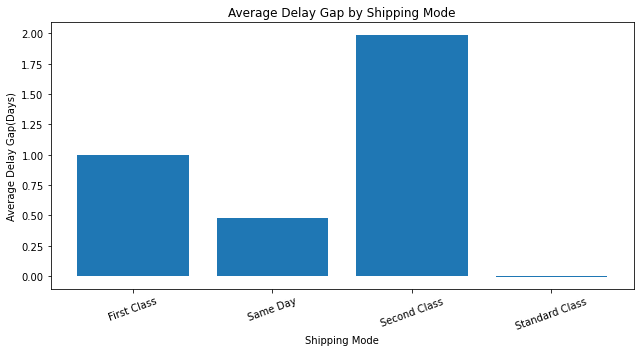

In [23]:
plt.figure(figsize=(9,5))
plt.bar(
    shipping_analysis["Shipping Mode"],
    shipping_analysis["Avg_Delay_Gap"]
)
plt.title("Average Delay Gap by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay Gap(Days)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

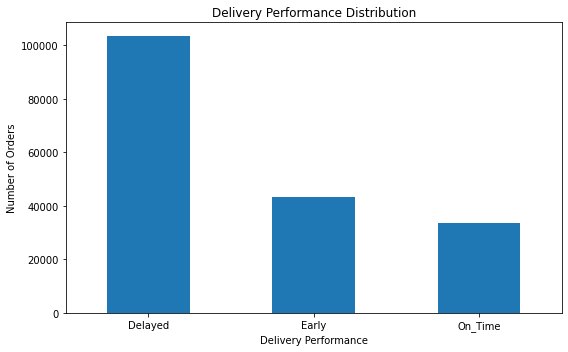

In [25]:
plt.figure(figsize=(8,5))
performance_counts.plot(kind="bar")
plt.title("Delivery Performance Distribution")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../outputs/figures/delivery_performance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [27]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
pd=pd.read_csv(
    "../outputs/cleaned_data/APL_Logistics_Cleaned.csv",
    encoding="latin1"
)
print("Dateset loaded:",df.shape)

Dateset loaded: (180519, 42)


In [28]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'Delay_Gap', 'Delivery_performance']


In [29]:
region_orders =(
    df["Order Region"]
    .value_counts()
    .reset_index()
)
region_orders.columns=[
    "Order Region",
    "Orders"
]
print(region_orders)

       Order Region  Orders
0   Central America   28341
1    Western Europe   27109
2     South America   14935
3           Oceania   10148
4   Northern Europe    9792
5    Southeast Asia    9539
6   Southern Europe    9431
7         Caribbean    8318
8       West of USA    7993
9        South Asia    7731
10     Eastern Asia    7280
11      East of USA    6915
12        West Asia    6009
13        US Center    5887
14    South of  USA    4045
15   Eastern Europe    3920
16      West Africa    3696
17     North Africa    3232
18      East Africa    1852
19   Central Africa    1677
20  Southern Africa    1157
21           Canada     959
22     Central Asia     553


In [30]:
region_analysis=(
    df.groupby("Order Region")
    .agg(
        Orders=("Order Region","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index()
)

In [32]:
region_analysis["Late_Risk_	Rate"]=(
    region_analysis["Late_Risk_Rate"]*100
).round(2)
region_analysis["Avg_Delay_Gap"]=(
    region_analysis["Avg_Delay_Gap"].round(2)
)
region_analysis

,Order Region,Orders,Avg_Delay_Gap,Late_Risk_Rate,Late_Risk_\tRate
0,Canada,959,0.39,0.488008,48.80
1,Caribbean,8318,0.55,0.530777,53.08
2,Central Africa,1677,0.64,0.579606,57.96
3,Central America,28341,0.56,0.547546,54.75
4,Central Asia,553,0.65,0.553345,55.33
5,East Africa,1852,0.57,0.559395,55.94
6,East of USA,6915,0.58,0.556616,55.66
7,Eastern Asia,7280,0.57,0.543269,54.33
8,Eastern Europe,3920,0.58,0.556633,55.66
9,North Africa,3232,0.55,0.545173,54.52


In [36]:
top_delayed_region = region_analysis.sort_values(
    "Avg_Delay_Gap",
    ascending=False
)
print(top_delayed_region)


       Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate  Late_Risk_\tRate
4      Central Asia     553           0.65        0.553345             55.33
2    Central Africa    1677           0.64        0.579606             57.96
22   Western Europe   27109           0.60        0.558486             55.85
13       South Asia    7731           0.60        0.562670             56.27
18        US Center    5887           0.59        0.552404             55.24
6       East of USA    6915           0.58        0.556616             55.66
8    Eastern Europe    3920           0.58        0.556633             55.66
14    South of  USA    4045           0.58        0.557726             55.77
5       East Africa    1852           0.57        0.559395             55.94
7      Eastern Asia    7280           0.57        0.543269             54.33
20        West Asia    6009           0.57        0.552837             55.28
21      West of USA    7993           0.56        0.539597             53.96

In [37]:
top_10_regions= top_delayed_region.head(10)
print(top_10_regions)

      Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate  Late_Risk_\tRate
4     Central Asia     553           0.65        0.553345             55.33
2   Central Africa    1677           0.64        0.579606             57.96
22  Western Europe   27109           0.60        0.558486             55.85
13      South Asia    7731           0.60        0.562670             56.27
18       US Center    5887           0.59        0.552404             55.24
6      East of USA    6915           0.58        0.556616             55.66
8   Eastern Europe    3920           0.58        0.556633             55.66
14   South of  USA    4045           0.58        0.557726             55.77
5      East Africa    1852           0.57        0.559395             55.94
7     Eastern Asia    7280           0.57        0.543269             54.33


In [39]:
top_risk_region = region_analysis.sort_values(
    "Late_Risk_Rate",
    ascending=False
)
print(top_risk_region.head(10))

      Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate  Late_Risk_\tRate
2   Central Africa    1677           0.64        0.579606             57.96
13      South Asia    7731           0.60        0.562670             56.27
5      East Africa    1852           0.57        0.559395             55.94
22  Western Europe   27109           0.60        0.558486             55.85
14   South of  USA    4045           0.58        0.557726             55.77
8   Eastern Europe    3920           0.58        0.556633             55.66
6      East of USA    6915           0.58        0.556616             55.66
15  Southeast Asia    9539           0.56        0.555299             55.53
4     Central Asia     553           0.65        0.553345             55.33
20       West Asia    6009           0.57        0.552837             55.28


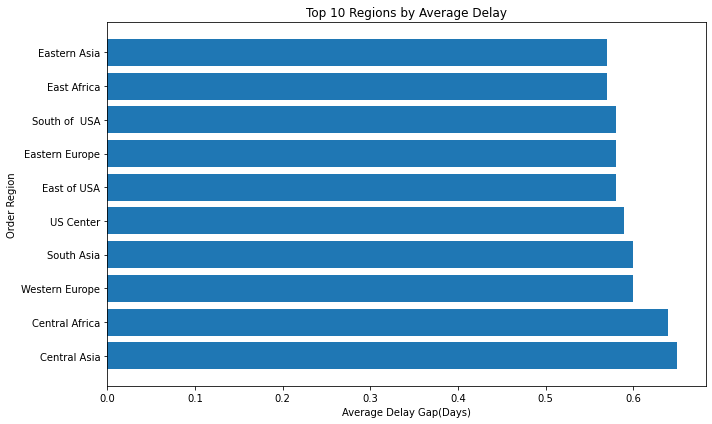

In [40]:
plt.figure(figsize=(10,6))
plt.barh(
    top_10_regions["Order Region"],
    top_10_regions["Avg_Delay_Gap"]
)
plt.title("Top 10 Regions by Average Delay")
plt.xlabel("Average Delay Gap(Days)")
plt.ylabel("Order Region")
plt.tight_layout()
plt.show()

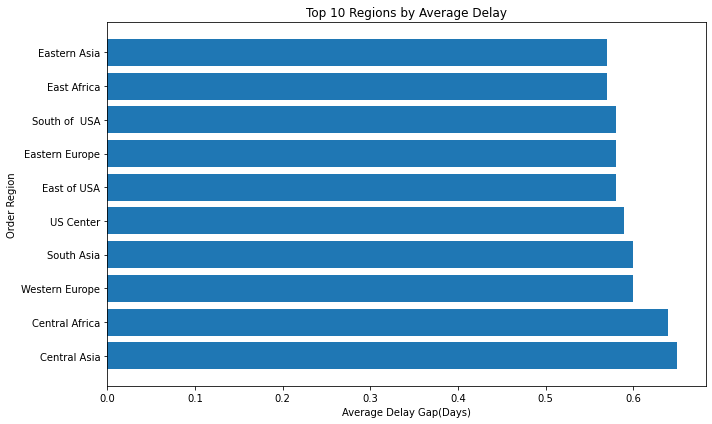

In [41]:
plt.figure(figsize=(10,6))
plt.barh(
    top_10_regions["Order Region"],
    top_10_regions["Avg_Delay_Gap"]
)
plt.title("Top 10 Regions by Average Delay")
plt.xlabel("Average Delay Gap(Days)")
plt.ylabel("Order Region")
plt.tight_layout()
plt.savefig(
    "../outputs/figures/top_delayed_regions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [55]:
market_analysis=(
    df.groupby("Market")
    .agg(
        Orders=("Market","size"),
        avg_delay_gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index()
)
market_analysis["Avg_Delay_Gap"] = (
    market_analysis["avg_delay_gap"].round(2)
)
market_analysis["Late_Risk_Rate"] = (
    market_analysis["Late_Risk_Rate"]*100
).round(2)
print(market_analysis)

         Market  Orders  avg_delay_gap  Late_Risk_Rate  Avg_Delay_Gap
0        Africa   11614       0.560014           54.59           0.56
1        Europe   50252       0.570843           55.21           0.57
2         LATAM   51594       0.557836           54.36           0.56
3  Pacific Asia   41260       0.569365           55.05           0.57
4          USCA   25799       0.568859           54.80           0.57


In [47]:
print(market_analysis.columns.tolist())

['Market', 'Orders', 'avg_delay_gap', 'Late_Risk_Rate']


In [56]:
market_analysis["Avg_Delay_Gap"]=(
    market_analysis["avg_delay_gap"].round(2)
)
market_analysis["Late_Risk_Rate"]=(
    market_analysis["Late_Risk_Rate"]*100
).round(2)
print(market_analysis)

         Market  Orders  avg_delay_gap  Late_Risk_Rate  Avg_Delay_Gap
0        Africa   11614       0.560014          5459.0           0.56
1        Europe   50252       0.570843          5521.0           0.57
2         LATAM   51594       0.557836          5436.0           0.56
3  Pacific Asia   41260       0.569365          5505.0           0.57
4          USCA   25799       0.568859          5480.0           0.57


In [57]:
top_markets= market_analysis.sort_values(
    "Avg_Delay_Gap",
    ascending=False
)
print(top_markets)

         Market  Orders  avg_delay_gap  Late_Risk_Rate  Avg_Delay_Gap
1        Europe   50252       0.570843          5521.0           0.57
3  Pacific Asia   41260       0.569365          5505.0           0.57
4          USCA   25799       0.568859          5480.0           0.57
0        Africa   11614       0.560014          5459.0           0.56
2         LATAM   51594       0.557836          5436.0           0.56


In [58]:
market_risk = market_analysis.sort_values(
    "Late_Risk_Rate",
    ascending=False
)
print(market_risk)

         Market  Orders  avg_delay_gap  Late_Risk_Rate  Avg_Delay_Gap
1        Europe   50252       0.570843          5521.0           0.57
3  Pacific Asia   41260       0.569365          5505.0           0.57
4          USCA   25799       0.568859          5480.0           0.57
0        Africa   11614       0.560014          5459.0           0.56
2         LATAM   51594       0.557836          5436.0           0.56


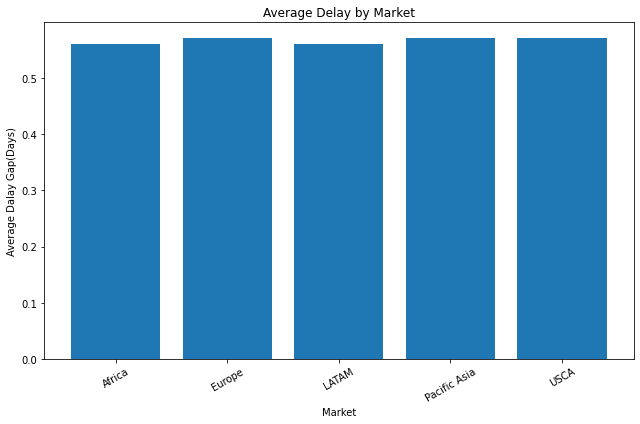

In [59]:
plt.figure(figsize=(9,6))
plt.bar(
    market_analysis["Market"],
    market_analysis["Avg_Delay_Gap"]
)
plt.title("Average Delay by Market")
plt.xlabel("Market")
plt.ylabel("Average Dalay Gap(Days)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [70]:
country_analysis =(
    df.groupby("Order Country")
    .agg(
        Orders=("Order Country","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
    .reset_index() 
)
country_analysis["Avg_Delay_Gap"]=(
    country_analysis["Avg_Delay_Gap"].round(2)
)
country_analysis["Late_Risk_Rate"]=(
    country_analysis["Late_Risk_Rate"]*100
).round(2)
print(country_analysis)

     Order Country  Orders  Avg_Delay_Gap  Late_Risk_Rate
0      AfganistÃ¡n     163           0.61           57.06
1          Albania      37           0.35           59.46
2         Alemania    9564           0.59           56.28
3           Angola     306           0.88           59.80
4    Arabia SaudÃ­     860           0.56           57.67
..             ...     ...            ...             ...
159        Vietnam     757           0.48           52.05
160          Yemen      71           0.83           59.15
161         Yibuti      31           0.61           67.74
162         Zambia     266           0.65           56.02
163       Zimbabue     190           0.56           55.79

[164 rows x 4 columns]


In [73]:
country_analysis=(
    df.groupby("Order Country")
    .agg(
        Order=("Order Country","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index()
)
country_analysis["Late_Risk_Rate"]=(
    country_analysis["Late_Risk_Rate"]*100
).round(2)
country_analysis["Avg_Delay_Gap"]=(
    country_analysis["Avg_Delay_Gap"].round(2)
)

In [74]:
top_countries = country_analysis.sort_values(
    "Avg_Delay_Gap",
    ascending=False
).head(15)
print(top_countries)

            Order Country  Order  Avg_Delay_Gap  Late_Risk_Rate
88             Luxemburgo     10           2.70          100.00
140        SudÃ¡n del Sur      5           2.20          100.00
125  RepÃºblica de Gambia      5           2.00          100.00
144    SÃ¡hara Occidental      2           2.00          100.00
137           Suazilandia      5           2.00          100.00
24                 ButÃ¡n      5           2.00          100.00
44                Eritrea      2           2.00          100.00
83                   Laos      6           1.83          100.00
46              Eslovenia      6           1.83           83.33
49                Estonia     29           1.55           96.55
62      Guinea Ecuatorial      2           1.50          100.00
97               Moldavia     78           1.41           69.23
35             Costa Rica     36           1.31           69.44
98               Mongolia     79           1.28           65.82
54                 GabÃ³n     45        

In [75]:
top_risk_country = country_analysis.sort_values(
    "Late_Risk_Rate",
    ascending=False
).head(15)
print(top_risk_country)

            Order Country  Order  Avg_Delay_Gap  Late_Risk_Rate
62      Guinea Ecuatorial      2           1.50          100.00
125  RepÃºblica de Gambia      5           2.00          100.00
83                   Laos      6           1.83          100.00
137           Suazilandia      5           2.00          100.00
7                 Armenia      5           1.00          100.00
88             Luxemburgo     10           2.70          100.00
140        SudÃ¡n del Sur      5           2.20          100.00
144    SÃ¡hara Occidental      2           2.00          100.00
24                 ButÃ¡n      5           2.00          100.00
44                Eritrea      2           2.00          100.00
49                Estonia     29           1.55           96.55
126  RepÃºblica del Congo     13           1.00           92.31
46              Eslovenia      6           1.83           83.33
64                 Guyana     19           0.84           78.95
153                TÃºnez     36        

c:\Users\Pooja\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\Pooja\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\backends\backend_agg.py:203: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0, flags=flags)


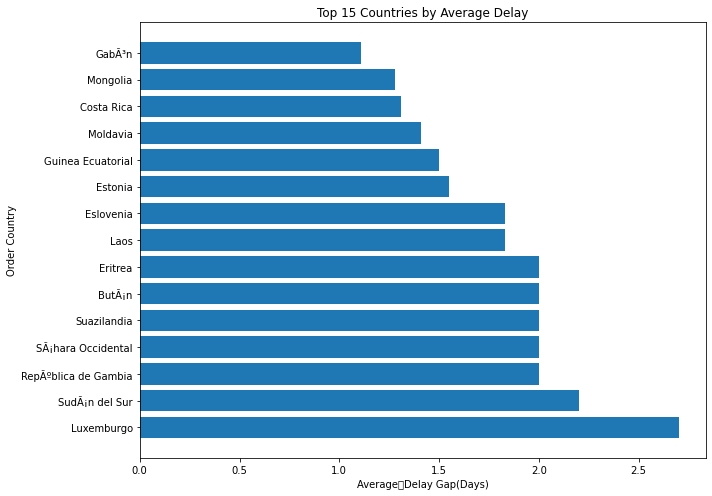

In [76]:
plt.figure(figsize=(10,7))
plt.barh(
    top_countries["Order Country"],
    top_countries["Avg_Delay_Gap"]
)
plt.title("Top 15 Countries by Average Delay")
plt.xlabel("Average	Delay Gap(Days)")
plt.ylabel("Order Country")
plt.tight_layout()
plt.show()

In [77]:
plt.savefig(
    "../outputs/figures/top_delayed_countries.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 432x288 with 0 Axes>

In [81]:
highest_risk_region = region_analysis.loc[
    region_analysis["Late_Risk_Rate"].idxmax()
]
highest_risk_market= market_analysis.loc[
    market_analysis["Late_Risk_Rate"].idxmax()
]
highest_risk_country = country_analysis.loc[
    country_analysis["Late_Risk_Rate"].idxmax()
]
print("Highest Risk Region:")
print(highest_risk_region)
print("\nHighest Risk Market:")
print(highest_risk_market)	
print("Highest Risk Country:")
print(highest_risk_country)

Highest Risk Region:
Order Region        Central Africa
Orders                        1677
Avg_Delay_Gap                 0.64
Late_Risk_Rate            0.579606
Late_Risk_\tRate             57.96
Name: 2, dtype: object

Highest Risk Market:
Market              Europe
Orders               50252
avg_delay_gap     0.570843
Late_Risk_Rate      5521.0
Avg_Delay_Gap         0.57
Name: 1, dtype: object
Highest Risk Country:
Order Country     Armenia
Order                   5
Avg_Delay_Gap         1.0
Late_Risk_Rate      100.0
Name: 7, dtype: object


In [84]:
country_reliable = country_analysis[
    country_analysis["Order"] >= 30
].sort_values(
    "Late_Risk_Rate",
    ascending=False
)
print(country_reliable.head(15))

            Order Country  Order  Avg_Delay_Gap  Late_Risk_Rate
153                TÃºnez     36           0.86           77.78
54                 GabÃ³n     45           1.11           77.78
151         TurkmenistÃ¡n     53           0.68           69.81
35             Costa Rica     36           1.31           69.44
97               Moldavia     78           1.41           69.23
18   Bosnia y Herzegovina     45           0.69           68.89
55                Georgia     93           0.62           68.82
161                Yibuti     31           0.61           67.74
40                Ecuador    294           0.64           67.01
98               Mongolia     79           1.28           65.82
100            Mozambique    244           0.86           63.93
109                NÃ­ger    108           0.79           63.89
135               Somalia    141           0.55           63.83
68               HungrÃ­a    179           0.63           62.57
92                Malasia    544        

In [86]:
regional_priority = region_analysis.sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(regional_priority)

       Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate  Late_Risk_\tRate
2    Central Africa    1677           0.64        0.579606             57.96
13       South Asia    7731           0.60        0.562670             56.27
5       East Africa    1852           0.57        0.559395             55.94
22   Western Europe   27109           0.60        0.558486             55.85
14    South of  USA    4045           0.58        0.557726             55.77
8    Eastern Europe    3920           0.58        0.556633             55.66
6       East of USA    6915           0.58        0.556616             55.66
15   Southeast Asia    9539           0.56        0.555299             55.53
4      Central Asia     553           0.65        0.553345             55.33
20        West Asia    6009           0.57        0.552837             55.28
18        US Center    5887           0.59        0.552404             55.24
3   Central America   28341           0.56        0.547546             54.75

In [88]:
import pandas as pd

In [89]:
print(type(pd))

<class 'module'>


In [6]:
import pandas as pd 
import os

In [7]:
print(pd.__version__)

1.3.2


In [3]:
import sys
print(sys.executable)

c:\Users\Pooja\AppData\Local\Programs\Python\Python39\python.exe


In [4]:
import sys
!{sys.executable} -m pip install openpyxl

You should consider upgrading via the 'c:\Users\Pooja\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:
import openpyxl
print("openpyxl version:",openpyxl.__version__)

openpyxl version: 3.1.5


In [4]:
import pandas as pd 
import openpyxl
print("pandas:",pd.__version__)
print("openPYXL:", openpyxl.__version__)

pandas: 1.3.2
openPYXL: 3.1.5


In [5]:
print(region_analysis.head())
print(market_analysis.head())
print(country_analysis.head())

NameError: name 'region_analysis' is not defined

In [7]:
import pandas as pd 
import numpy as np	
import matplotlib.pyplot as plt

df =pd.read_csv(
    "../outputs/cleaned_data/APL_Logistics_Cleaned.csv",
    encoding="latin1"
)
print("Dataset loaded:",df.shape)

Dataset loaded: (180519, 42)


In [8]:
print([
    "Market",
    "Order Region",
    "Order Country",
    "Delay_Gap",
    "Late_delivery_risk"
])
print(df.columns.tolist())

['Market', 'Order Region', 'Order Country', 'Delay_Gap', 'Late_delivery_risk']
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'Delay_Gap', 'Delivery_performance']


In [9]:
region_analysis =(
    df.groupby("Order Region")
    .agg(
        Orders=("Order Region","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
     				)
									.reset_index()
)
region_analysis["Avg_Delay_Gap"]=(
    region_analysis["Avg_Delay_Gap"].round(2)
)
region_analysis["Late_Risk_Rate"]=(
    region_analysis["Late_Risk_Rate"]*100	
).round(2)
print(region_analysis.head())

      Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate
0           Canada     959           0.39           48.80
1        Caribbean    8318           0.55           53.08
2   Central Africa    1677           0.64           57.96
3  Central America   28341           0.56           54.75
4     Central Asia     553           0.65           55.33


In [12]:
market_analysis=(
    df.groupby("Market")
    .agg(
        Orders=("Market","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
     .reset_index()
)
market_analysis["Avg_Delay_Gap"]=(
    market_analysis["Avg_Delay_Gap"].round(2)
)
market_analysis["Late_Risk_Rate"]=(
    market_analysis["Late_Risk_Rate"]*100
).round(2)
print(market_analysis.head())

         Market  Orders  Avg_Delay_Gap  Late_Risk_Rate
0        Africa   11614           0.56           54.59
1        Europe   50252           0.57           55.21
2         LATAM   51594           0.56           54.36
3  Pacific Asia   41260           0.57           55.05
4          USCA   25799           0.57           54.80


In [14]:
country_analysis=(
    df.groupby("Order Country")
    .agg(
        Orders=("Order Country","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
     .reset_index()
)
country_analysis["Avg_Delay_Gap"]=(
    country_analysis["Avg_Delay_Gap"].round(2)
)
country_analysis["Late_Risk_Rate"]=(
    country_analysis["Late_Risk_Rate"]*100
).round(2)
print(country_analysis.head())

   Order Country  Orders  Avg_Delay_Gap  Late_Risk_Rate
0    AfganistÃ¡n     163           0.61           57.06
1        Albania      37           0.35           59.46
2       Alemania    9564           0.59           56.28
3         Angola     306           0.88           59.80
4  Arabia SaudÃ­     860           0.56           57.67


In [15]:
print("REGION")
print(region_analysis.head())
print("\nMARKET")
print(market_analysis.head())
print("\nCOUNTRY")
print(country_analysis.head())

REGION
      Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate
0           Canada     959           0.39           48.80
1        Caribbean    8318           0.55           53.08
2   Central Africa    1677           0.64           57.96
3  Central America   28341           0.56           54.75
4     Central Asia     553           0.65           55.33

MARKET
         Market  Orders  Avg_Delay_Gap  Late_Risk_Rate
0        Africa   11614           0.56           54.59
1        Europe   50252           0.57           55.21
2         LATAM   51594           0.56           54.36
3  Pacific Asia   41260           0.57           55.05
4          USCA   25799           0.57           54.80

COUNTRY
   Order Country  Orders  Avg_Delay_Gap  Late_Risk_Rate
0    AfganistÃ¡n     163           0.61           57.06
1        Albania      37           0.35           59.46
2       Alemania    9564           0.59           56.28
3         Angola     306           0.88           59.80
4  Arabia SaudÃ­  

In [16]:
with pd.ExcelWriter(
    "../outputs/regional_maket_analysis.xlsx",
    engine="openpyxl"
)as writer:

				region_analysis.to_excel(
					writer,
					sheet_name="Region Analysis",
					index=False
				)

				market_analysis.to_excel(
					writer,
					sheet_name="Market Analysis",
					index=False
				)

				country_analysis.to_excel(
					writer,
					sheet_name="Country Analysis",
					index=False
				)

print("Regional and market analysis saved!")				

Regional and market analysis saved!


In [17]:
shipping_analysis=(
    df.groupby("Shipping Mode")
    .agg(
        Orders=("Shipping Mode","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index()
                
)
shipping_analysis["Avg_Delay_Gap"]=(
    shipping_analysis["Avg_Delay_Gap"].round(2)
)
shipping_analysis["Late_Risk_Rate"]=(
    shipping_analysis["Late_Risk_Rate"]*100
).round(2)
print(shipping_analysis)

    Shipping Mode  Orders  Avg_Delay_Gap  Late_Risk_Rate
0     First Class   27814           1.00           95.32
1        Same Day    9737           0.48           45.74
2    Second Class   35216           1.99           76.63
3  Standard Class  107752          -0.00           38.07


In [18]:
shipping_analysis.sort_values(
    "Avg_Delay_Gap",
    ascending=False
)

,Shipping Mode,Orders,Avg_Delay_Gap,Late_Risk_Rate
2,Second Class,35216,1.99,76.63
0,First Class,27814,1.00,95.32
1,Same Day,9737,0.48,45.74
3,Standard Class,107752,-0.00,38.07


In [19]:
shipping_delay=shipping_analysis.sort_values(
    "Avg_Delay_Gap",
    ascending=False
)
print("Shipping Modes by Average Dealy:")
print(shipping_delay)

Shipping Modes by Average Dealy:
    Shipping Mode  Orders  Avg_Delay_Gap  Late_Risk_Rate
2    Second Class   35216           1.99           76.63
0     First Class   27814           1.00           95.32
1        Same Day    9737           0.48           45.74
3  Standard Class  107752          -0.00           38.07


In [20]:
shipping_risk=shipping_analysis.sort_values(
    "Late_Risk_Rate",
    ascending=False
)
print("Shipping Modes by Late Delivery Risk:")
print(shipping_risk)

Shipping Modes by Late Delivery Risk:
    Shipping Mode  Orders  Avg_Delay_Gap  Late_Risk_Rate
0     First Class   27814           1.00           95.32
2    Second Class   35216           1.99           76.63
1        Same Day    9737           0.48           45.74
3  Standard Class  107752          -0.00           38.07


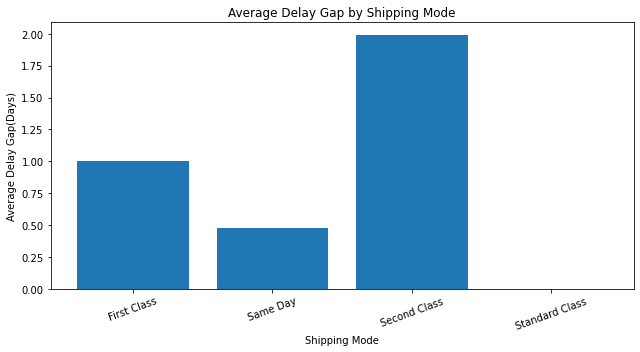

In [21]:
plt.figure(figsize=(9,5))
plt.bar(
    shipping_analysis["Shipping Mode"],
    shipping_analysis["Avg_Delay_Gap"]
)
plt.title("Average Delay Gap by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay Gap(Days)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [22]:
plt.savefig(
    "../outputs/figures/shipping_mode_delay.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 432x288 with 0 Axes>

In [23]:
shipping_priority = shipping_analysis.sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(shipping_priority)

    Shipping Mode  Orders  Avg_Delay_Gap  Late_Risk_Rate
0     First Class   27814           1.00           95.32
2    Second Class   35216           1.99           76.63
1        Same Day    9737           0.48           45.74
3  Standard Class  107752          -0.00           38.07


In [25]:
customer_analysis = (
    df.groupby("Customer Segment")
    .agg(
        Order=("Customer Segment","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index()
)
customer_analysis["Avg_Dealy_Gap"]=(
    customer_analysis["Avg_Delay_Gap"].round(2)
)
customer_analysis["Late_Risk_Rate"]=(
    customer_analysis["Late_Risk_Rate"]*100
).round(2)
print(customer_analysis)

  Customer Segment  Order  Avg_Delay_Gap  Late_Risk_Rate  Avg_Dealy_Gap
0         Consumer  93504       0.564917           54.81           0.56
1        Corporate  54789       0.560185           54.72           0.56
2      Home Office  32226       0.577949           55.07           0.58


In [27]:
customer_delay=customer_analysis.sort_values(
    "Avg_Delay_Gap",	
    ascending=False
)
print(customer_delay)

  Customer Segment  Order  Avg_Delay_Gap  Late_Risk_Rate  Avg_Dealy_Gap
2      Home Office  32226       0.577949           55.07           0.58
0         Consumer  93504       0.564917           54.81           0.56
1        Corporate  54789       0.560185           54.72           0.56


In [29]:
customer_risk= customer_analysis.sort_values(
    "Late_Risk_Rate",
    ascending=False
)
print(customer_risk)

  Customer Segment  Order  Avg_Delay_Gap  Late_Risk_Rate  Avg_Dealy_Gap
2      Home Office  32226       0.577949           55.07           0.58
0         Consumer  93504       0.564917           54.81           0.56
1        Corporate  54789       0.560185           54.72           0.56


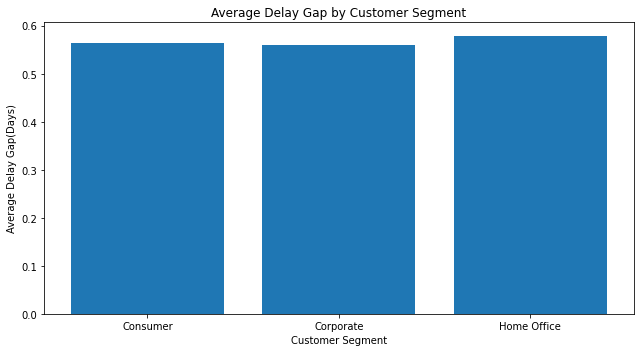

In [31]:
plt.figure(figsize=(9,5))
plt.bar(
    customer_analysis["Customer Segment"],
    customer_analysis["Avg_Delay_Gap"]
)
plt.title("Average Delay Gap by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Delay Gap(Days)")
plt.tight_layout()
plt.show()

In [32]:
plt.savefig(
    "../outputs/figures/customer_segment_delay.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 432x288 with 0 Axes>

In [33]:
customer_priority = customer_analysis.sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(customer_priority)

  Customer Segment  Order  Avg_Delay_Gap  Late_Risk_Rate  Avg_Dealy_Gap
2      Home Office  32226       0.577949           55.07           0.58
0         Consumer  93504       0.564917           54.81           0.56
1        Corporate  54789       0.560185           54.72           0.56


In [37]:
combined_analysis =(
    df.groupby(["Shipping Mode","Customer Segment"])
    .agg(
        Orders=("Shipping Mode","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index() 
)
combined_analysis["Avg_Delay_Gap"]=(
    combined_analysis["Avg_Delay_Gap"].round(2)
)
combined_analysis["Late_Risk_Rate"]=(
    combined_analysis["Late_Risk_Rate"]*100
).round(2)
print(combined_analysis)


     Shipping Mode Customer Segment  Orders  Avg_Delay_Gap  Late_Risk_Rate
0      First Class         Consumer   14407           1.00           95.15
1      First Class        Corporate    8282           1.00           95.44
2      First Class      Home Office    5125           1.00           95.63
3         Same Day         Consumer    5148           0.49           46.48
4         Same Day        Corporate    2975           0.48           46.18
5         Same Day      Home Office    1614           0.44           42.57
6     Second Class         Consumer   17997           1.98           76.12
7     Second Class        Corporate   10950           2.00           77.90
8     Second Class      Home Office    6269           2.00           75.90
9   Standard Class         Consumer   55952           0.00           38.33
10  Standard Class        Corporate   32582          -0.03           37.36
11  Standard Class      Home Office   19218           0.01           38.51


In [38]:
high_risk_combination = combined_analysis.sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(high_risk_combination.head(15))

     Shipping Mode Customer Segment  Orders  Avg_Delay_Gap  Late_Risk_Rate
2      First Class      Home Office    5125           1.00           95.63
1      First Class        Corporate    8282           1.00           95.44
0      First Class         Consumer   14407           1.00           95.15
7     Second Class        Corporate   10950           2.00           77.90
6     Second Class         Consumer   17997           1.98           76.12
8     Second Class      Home Office    6269           2.00           75.90
3         Same Day         Consumer    5148           0.49           46.48
4         Same Day        Corporate    2975           0.48           46.18
5         Same Day      Home Office    1614           0.44           42.57
11  Standard Class      Home Office   19218           0.01           38.51
9   Standard Class         Consumer   55952           0.00           38.33
10  Standard Class        Corporate   32582          -0.03           37.36


In [39]:
relibal_risk = combined_analysis[
    combined_analysis["Orders"] >=30
].sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(relibal_risk.head(15))

     Shipping Mode Customer Segment  Orders  Avg_Delay_Gap  Late_Risk_Rate
2      First Class      Home Office    5125           1.00           95.63
1      First Class        Corporate    8282           1.00           95.44
0      First Class         Consumer   14407           1.00           95.15
7     Second Class        Corporate   10950           2.00           77.90
6     Second Class         Consumer   17997           1.98           76.12
8     Second Class      Home Office    6269           2.00           75.90
3         Same Day         Consumer    5148           0.49           46.48
4         Same Day        Corporate    2975           0.48           46.18
5         Same Day      Home Office    1614           0.44           42.57
11  Standard Class      Home Office   19218           0.01           38.51
9   Standard Class         Consumer   55952           0.00           38.33
10  Standard Class        Corporate   32582          -0.03           37.36


In [42]:
mode_market_analysis=(
    df.groupby(["Shipping Mode","Market"])
    .agg(
        Order=("Shipping Mode","size"),
        Avg_Delay_Gap=("Delay_Gap","mean"),
        Late_Risk_Rate=("Late_delivery_risk","mean")
				)
                .reset_index()
               
)
mode_market_analysis["Avg_Delay_Gap"]=(
    mode_market_analysis["Avg_Delay_Gap"].round(2)
)
mode_market_analysis["Late_Risk_Rate"]=(
    mode_market_analysis["Late_Risk_Rate"]*100
).round(2)
print(mode_market_analysis.head())

  Shipping Mode        Market  Order  Avg_Delay_Gap  Late_Risk_Rate
0   First Class        Africa   1727            1.0           96.99
1   First Class        Europe   7892            1.0           95.82
2   First Class         LATAM   7886            1.0           94.74
3   First Class  Pacific Asia   6301            1.0           95.08
4   First Class          USCA   4008            1.0           95.16


In [44]:
top_mode_market_risk=(
    mode_market_analysis[
        mode_market_analysis["Order"] >=30
				]
                .sort_values(
                    ["Late_Risk_Rate","Avg_Delay_Gap"],
                    ascending=False
																)
                                                                .head(15)
)
print(top_mode_market_risk)

   Shipping Mode        Market  Order  Avg_Delay_Gap  Late_Risk_Rate
0    First Class        Africa   1727           1.00           96.99
1    First Class        Europe   7892           1.00           95.82
4    First Class          USCA   4008           1.00           95.16
3    First Class  Pacific Asia   6301           1.00           95.08
2    First Class         LATAM   7886           1.00           94.74
10  Second Class        Africa   2164           1.98           77.40
13  Second Class  Pacific Asia   8147           2.00           77.24
11  Second Class        Europe   9861           2.00           77.03
14  Second Class          USCA   5105           1.98           76.65
12  Second Class         LATAM   9939           1.98           75.56
7       Same Day         LATAM   2650           0.51           48.04
6       Same Day        Europe   2759           0.49           46.43
9       Same Day          USCA   1434           0.45           44.42
5       Same Day        Africa    

In [45]:
with pd.ExcelWriter(
    "../outputs/delay_risk_analysis.xlsx",
    engine="openpyxl"
)as writer:
    shipping_analysis.to_excel(
        writer,
        sheet_name="Shipping Mode",
        index=False
				)
    customer_analysis.to_excel(
        writer,
        sheet_name="Customer Segment",
        index=False
				)
    combined_analysis.to_excel(
        writer,
        sheet_name="Mode Customer Risk",
        index=False
				)
    mode_market_analysis.to_excel(
        writer,
        sheet_name="Mode Market Risk",
        index=False
				)
    print("Delay risk analysis saved successfully!")

Delay risk analysis saved successfully!


In [46]:
delay_stats=df["Delay_Gap"].describe()
print(delay_stats)

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delay_Gap, dtype: float64


In [47]:
print("Avergar Dalay:",round(df["Delay_Gap"].mean(),2))
print("Median Dalay:",round(df["Delay_Gap"].median(),2))
print("Maximum Delay:",round(df["Delay_Gap"].max(),2))
print("Minimum Delay:",round(df["Delay_Gap"].min(),2))

Avergar Dalay: 0.57
Median Dalay: 1.0
Maximum Delay: 4
Minimum Delay: -2


In [48]:
overall_risk = df["Late_delivery_risk"].mean()*100
print(
    "Overall Late Delivery Risk:",
    round(overall_risk,2),
    "%"
)

Overall Late Delivery Risk: 54.83 %


In [49]:
print(df["Delivery_performance"].value_counts())

Delayed    103400
Early       43366
On_Time     33753
Name: Delivery_performance, dtype: int64


In [50]:
risk_counts = df["Late_delivery_risk"].value_counts()
print(risk_counts)

1    98977
0    81542
Name: Late_delivery_risk, dtype: int64


In [51]:
risk_percrnt =(
    df["Late_delivery_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(risk_percrnt)

1    54.83
0    45.17
Name: Late_delivery_risk, dtype: float64


In [52]:
print(
    df[
        [
            "Days for shipping (real)",
            "Days for shipment (scheduled)",
            "Delay_Gap",
												"Late_delivery_risk"
								]
				].dtypes
)

Days for shipping (real)         int64
Days for shipment (scheduled)    int64
Delay_Gap                        int64
Late_delivery_risk               int64
dtype: object


In [54]:
correlation = df[
    [
        "Days for shipping (real)",
        "Days for shipment (scheduled)",
        "Delay_Gap",
        "Late_delivery_risk"
				]
].corr()
print(correlation.round(2))

                               Days for shipping (real)  \
Days for shipping (real)                           1.00   
Days for shipment (scheduled)                      0.52   
Delay_Gap                                          0.61   
Late_delivery_risk                                 0.40   

                               Days for shipment (scheduled)  Delay_Gap  \
Days for shipping (real)                                0.52       0.61   
Days for shipment (scheduled)                           1.00      -0.36   
Delay_Gap                                              -0.36       1.00   
Late_delivery_risk                                     -0.37       0.78   

                               Late_delivery_risk  
Days for shipping (real)                     0.40  
Days for shipment (scheduled)               -0.37  
Delay_Gap                                    0.78  
Late_delivery_risk                           1.00  


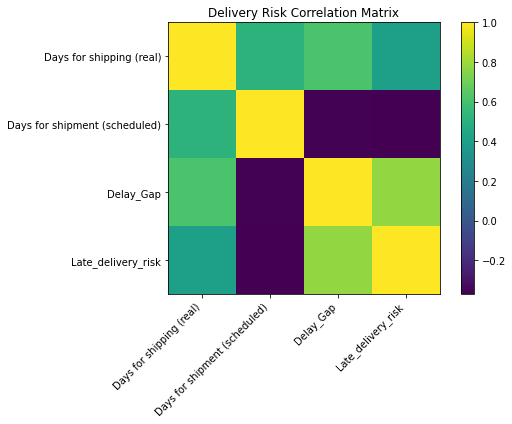

In [55]:
plt.figure(figsize=(8,6))
plt.imshow(correlation)
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation.columns)),
				correlation.columns
)

plt.colorbar()

plt.title("Delivery Risk Correlation Matrix")
plt.tight_layout()
plt.savefig(
    "../outputs/figures/delivery_risk_correlation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [56]:
region_risk = region_analysis.sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(region_risk.head(10))

      Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate
2   Central Africa    1677           0.64           57.96
13      South Asia    7731           0.60           56.27
5      East Africa    1852           0.57           55.94
22  Western Europe   27109           0.60           55.85
14   South of  USA    4045           0.58           55.77
6      East of USA    6915           0.58           55.66
8   Eastern Europe    3920           0.58           55.66
15  Southeast Asia    9539           0.56           55.53
4     Central Asia     553           0.65           55.33
20       West Asia    6009           0.57           55.28


In [57]:
market_risk = market_analysis.sort_values(
	["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(market_risk.head(10))

         Market  Orders  Avg_Delay_Gap  Late_Risk_Rate
1        Europe   50252           0.57           55.21
3  Pacific Asia   41260           0.57           55.05
4          USCA   25799           0.57           54.80
0        Africa   11614           0.56           54.59
2         LATAM   51594           0.56           54.36


In [58]:
country_risk = country_analysis.sort_values(
	["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(country_risk.head(10))

            Order Country  Orders  Avg_Delay_Gap  Late_Risk_Rate
88             Luxemburgo      10           2.70           100.0
140        SudÃ¡n del Sur       5           2.20           100.0
24                 ButÃ¡n       5           2.00           100.0
44                Eritrea       2           2.00           100.0
125  RepÃºblica de Gambia       5           2.00           100.0
137           Suazilandia       5           2.00           100.0
144    SÃ¡hara Occidental       2           2.00           100.0
83                   Laos       6           1.83           100.0
62      Guinea Ecuatorial       2           1.50           100.0
7                 Armenia       5           1.00           100.0


In [59]:
shipping_risk = shipping_analysis.sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
				ascending=False
)
print(shipping_risk)

    Shipping Mode  Orders  Avg_Delay_Gap  Late_Risk_Rate
0     First Class   27814           1.00           95.32
2    Second Class   35216           1.99           76.63
1        Same Day    9737           0.48           45.74
3  Standard Class  107752          -0.00           38.07


In [60]:
customer_risk = customer_analysis.sort_values(
    ["Late_Risk_Rate","Avg_Delay_Gap"],
    ascending=False
)
print(customer_risk)

  Customer Segment  Order  Avg_Delay_Gap  Late_Risk_Rate  Avg_Dealy_Gap
2      Home Office  32226       0.577949           55.07           0.58
0         Consumer  93504       0.564917           54.81           0.56
1        Corporate  54789       0.560185           54.72           0.56


In [77]:
with pd.ExcelWriter(
    "../outputs/statistical_risk_analysis.xlsx",
    engine="openpyxl"
) as writer:

    delay_stats.to_frame(
        name="Value"
    ).to_excel(
        writer,
        sheet_name="Delay Statistics"
    )

    region_risk.to_excel(
        writer,
        sheet_name="Region Risk",
        index=False
    )

    market_risk.to_excel(
        writer,
        sheet_name="Market Risk",
        index=False
    )

    country_risk.to_excel(
        writer,
        sheet_name="Country Risk",
        index=False
    )

    shipping_risk.to_excel(
        writer,
        sheet_name="Shipping Risk",
        index=False
    )

    customer_risk.to_excel(
        writer,
        sheet_name="Customer Risk",
        index=False
    )

    correlation.to_excel(
        writer,
        sheet_name="Correlation"
    )

print("Statistical and risk analysis saved successfully!")

Statistical and risk analysis saved successfully!


In [78]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'Delay_Gap', 'Delivery_performance']


In [82]:
performance_counts= df["Late_delivery_risk"].value_counts()

print(performance_counts)

1    98977
0    81542
Name: Late_delivery_risk, dtype: int64


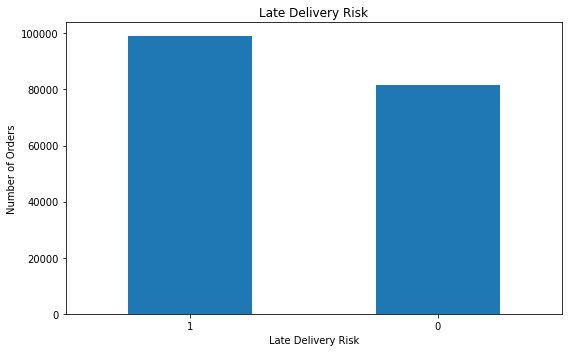

In [83]:
plt.figure(figsize=(8, 5))

performance_counts.plot(kind="bar")

plt.title("Late Delivery Risk")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/delivery_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
risk_labels = {
    0: "On-Time / Low Risk",
    1: "Late Risk"
}

performance_counts.index = performance_counts.index.map(risk_labels)

print(performance_counts)

NaN    98977
NaN    81542
Name: Late_delivery_risk, dtype: int64


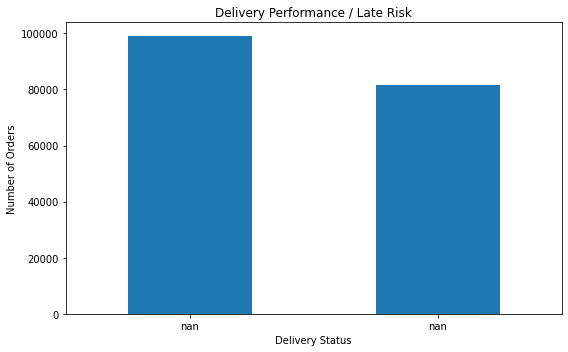

In [86]:
plt.figure(figsize=(8, 5))

performance_counts.plot(kind="bar")

plt.title("Delivery Performance / Late Risk")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/delivery_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'Delay_Gap', 'Delivery_performance']


In [88]:
print(df["Delay_Gap"].describe())

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delay_Gap, dtype: float64


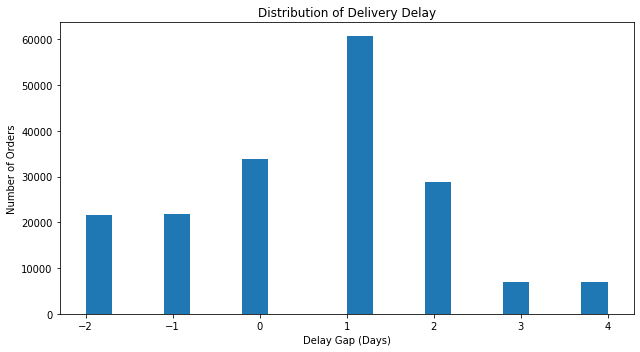

In [89]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Delay_Gap"].dropna(),
    bins=20
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay Gap (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/delay_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
import os

print(
    os.path.exists(
        "../outputs/figures/delay_distribution.png"
    )
)

True


In [91]:
print(
    df["Delay_Gap"]
    .value_counts()
    .sort_index()
    .head(15)
)

-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: Delay_Gap, dtype: int64


In [92]:
delayed_orders = (
    df["Delay_Gap"] > 0
).sum()

total_orders = len(df)

print("Total Orders:", total_orders)
print("Delayed Orders:", delayed_orders)

print(
    "Delay Rate:",
    round((delayed_orders / total_orders) * 100, 2),
    "%"
)

Total Orders: 180519
Delayed Orders: 103400
Delay Rate: 57.28 %


In [93]:
print(region_analysis.head())
print(region_analysis.columns.tolist())

      Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate
0           Canada     959           0.39           48.80
1        Caribbean    8318           0.55           53.08
2   Central Africa    1677           0.64           57.96
3  Central America   28341           0.56           54.75
4     Central Asia     553           0.65           55.33
['Order Region', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [94]:
top_regions = (
    region_analysis
    .sort_values(
        "Avg_Delay_Gap",
        ascending=False
    )
    .head(10)
)

print(top_regions)

      Order Region  Orders  Avg_Delay_Gap  Late_Risk_Rate
4     Central Asia     553           0.65           55.33
2   Central Africa    1677           0.64           57.96
22  Western Europe   27109           0.60           55.85
13      South Asia    7731           0.60           56.27
18       US Center    5887           0.59           55.24
6      East of USA    6915           0.58           55.66
8   Eastern Europe    3920           0.58           55.66
14   South of  USA    4045           0.58           55.77
5      East Africa    1852           0.57           55.94
7     Eastern Asia    7280           0.57           54.33


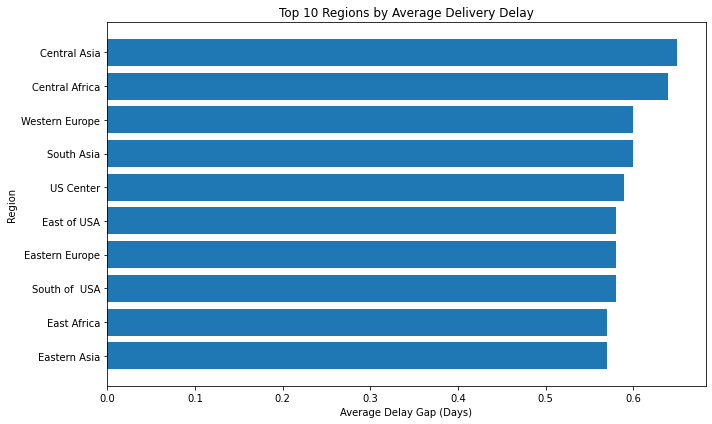

In [95]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_regions["Order Region"],
    top_regions["Avg_Delay_Gap"]
)

plt.title("Top 10 Regions by Average Delivery Delay")
plt.xlabel("Average Delay Gap (Days)")
plt.ylabel("Region")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/top_delayed_regions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [96]:
import os

print(
    os.path.exists(
        "../outputs/figures/top_delayed_regions.png"
    )
)

True


In [97]:
print(region_analysis.columns.tolist())

['Order Region', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [98]:
print(market_analysis.head())
print(market_analysis.columns.tolist())

         Market  Orders  Avg_Delay_Gap  Late_Risk_Rate
0        Africa   11614           0.56           54.59
1        Europe   50252           0.57           55.21
2         LATAM   51594           0.56           54.36
3  Pacific Asia   41260           0.57           55.05
4          USCA   25799           0.57           54.80
['Market', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [99]:
market_chart = (
    market_analysis
    .sort_values(
        "Late_Risk_Rate",
        ascending=False
    )
)

print(market_chart)

         Market  Orders  Avg_Delay_Gap  Late_Risk_Rate
1        Europe   50252           0.57           55.21
3  Pacific Asia   41260           0.57           55.05
4          USCA   25799           0.57           54.80
0        Africa   11614           0.56           54.59
2         LATAM   51594           0.56           54.36


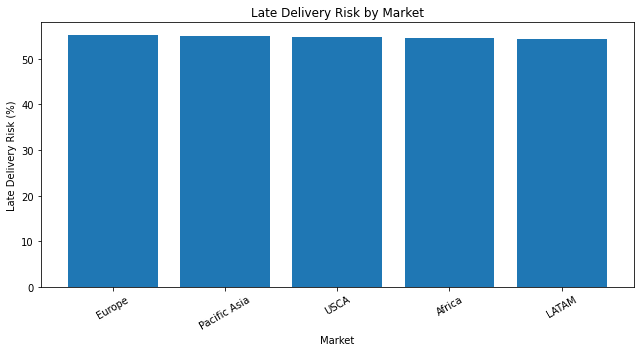

In [100]:
plt.figure(figsize=(9, 5))

plt.bar(
    market_chart["Market"],
    market_chart["Late_Risk_Rate"]
)

plt.title("Late Delivery Risk by Market")
plt.xlabel("Market")
plt.ylabel("Late Delivery Risk (%)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/market_late_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [101]:
import os

print(
    os.path.exists(
        "../outputs/figures/market_late_risk.png"
    )
)

True


In [102]:
highest_risk_market = market_chart.iloc[0]

print("Highest Risk Market:")
print(highest_risk_market)

Highest Risk Market:
Market            Europe
Orders             50252
Avg_Delay_Gap       0.57
Late_Risk_Rate     55.21
Name: 1, dtype: object


In [103]:
print(market_analysis.columns.tolist())

['Market', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [104]:
print(shipping_analysis.head())
print(shipping_analysis.columns.tolist())

    Shipping Mode  Orders  Avg_Delay_Gap  Late_Risk_Rate
0     First Class   27814           1.00           95.32
1        Same Day    9737           0.48           45.74
2    Second Class   35216           1.99           76.63
3  Standard Class  107752          -0.00           38.07
['Shipping Mode', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [105]:
shipping_chart = (
    shipping_analysis
    .sort_values(
        "Late_Risk_Rate",
        ascending=False
    )
)

print(shipping_chart)

    Shipping Mode  Orders  Avg_Delay_Gap  Late_Risk_Rate
0     First Class   27814           1.00           95.32
2    Second Class   35216           1.99           76.63
1        Same Day    9737           0.48           45.74
3  Standard Class  107752          -0.00           38.07


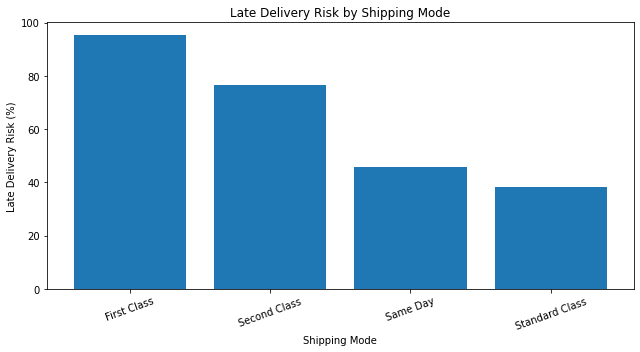

In [106]:
plt.figure(figsize=(9, 5))

plt.bar(
    shipping_chart["Shipping Mode"],
    shipping_chart["Late_Risk_Rate"]
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Risk (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/shipping_mode_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [107]:
highest_risk_shipping = shipping_chart.iloc[0]

print("Highest Risk Shipping Mode:")
print(highest_risk_shipping)

Highest Risk Shipping Mode:
Shipping Mode     First Class
Orders                  27814
Avg_Delay_Gap             1.0
Late_Risk_Rate          95.32
Name: 0, dtype: object


In [108]:
import os

print(
    os.path.exists(
        "../outputs/figures/shipping_mode_risk.png"
    )
)

True


In [109]:
print(shipping_analysis.columns.tolist())

['Shipping Mode', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [110]:
print(customer_analysis.head())
print(customer_analysis.columns.tolist())

  Customer Segment  Order  Avg_Delay_Gap  Late_Risk_Rate  Avg_Dealy_Gap
0         Consumer  93504       0.564917           54.81           0.56
1        Corporate  54789       0.560185           54.72           0.56
2      Home Office  32226       0.577949           55.07           0.58
['Customer Segment', 'Order', 'Avg_Delay_Gap', 'Late_Risk_Rate', 'Avg_Dealy_Gap']


In [111]:
customer_chart = (
    customer_analysis
    .sort_values(
        "Late_Risk_Rate",
        ascending=False
    )
)

print(customer_chart)

  Customer Segment  Order  Avg_Delay_Gap  Late_Risk_Rate  Avg_Dealy_Gap
2      Home Office  32226       0.577949           55.07           0.58
0         Consumer  93504       0.564917           54.81           0.56
1        Corporate  54789       0.560185           54.72           0.56


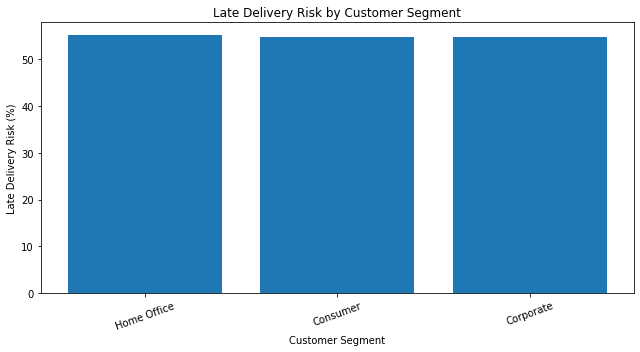

In [112]:
plt.figure(figsize=(9, 5))

plt.bar(
    customer_chart["Customer Segment"],
    customer_chart["Late_Risk_Rate"]
)

plt.title("Late Delivery Risk by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Late Delivery Risk (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/customer_segment_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
highest_risk_customer = customer_chart.iloc[0]

print("Highest Risk Customer Segment:")
print(highest_risk_customer)

Highest Risk Customer Segment:
Customer Segment    Home Office
Order                     32226
Avg_Delay_Gap          0.577949
Late_Risk_Rate            55.07
Avg_Dealy_Gap              0.58
Name: 2, dtype: object


In [114]:
import os

print(
    os.path.exists(
        "../outputs/figures/customer_segment_risk.png"
    )
)

True


In [115]:
print(customer_analysis.columns.tolist())

['Customer Segment', 'Order', 'Avg_Delay_Gap', 'Late_Risk_Rate', 'Avg_Dealy_Gap']


In [116]:
print(country_analysis.head())
print(country_analysis.columns.tolist())

   Order Country  Orders  Avg_Delay_Gap  Late_Risk_Rate
0    AfganistÃ¡n     163           0.61           57.06
1        Albania      37           0.35           59.46
2       Alemania    9564           0.59           56.28
3         Angola     306           0.88           59.80
4  Arabia SaudÃ­     860           0.56           57.67
['Order Country', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [117]:
top_countries = (
    country_analysis
    .sort_values(
        "Avg_Delay_Gap",
        ascending=False
    )
    .head(10)
)

print(top_countries)

            Order Country  Orders  Avg_Delay_Gap  Late_Risk_Rate
88             Luxemburgo      10           2.70          100.00
140        SudÃ¡n del Sur       5           2.20          100.00
125  RepÃºblica de Gambia       5           2.00          100.00
144    SÃ¡hara Occidental       2           2.00          100.00
137           Suazilandia       5           2.00          100.00
24                 ButÃ¡n       5           2.00          100.00
44                Eritrea       2           2.00          100.00
83                   Laos       6           1.83          100.00
46              Eslovenia       6           1.83           83.33
49                Estonia      29           1.55           96.55


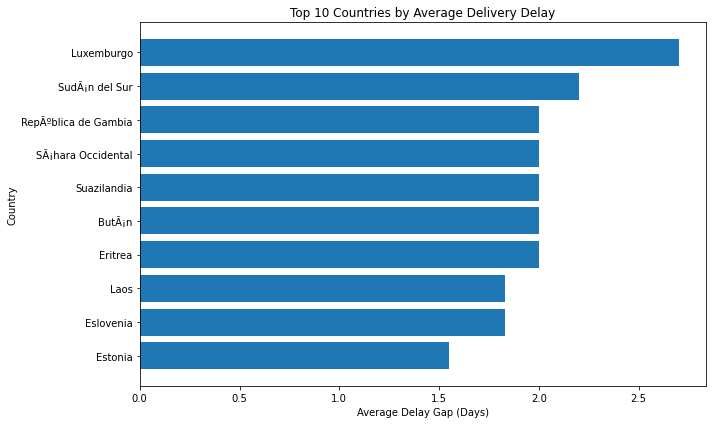

In [118]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Order Country"],
    top_countries["Avg_Delay_Gap"]
)

plt.title("Top 10 Countries by Average Delivery Delay")
plt.xlabel("Average Delay Gap (Days)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/top_delayed_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [119]:
highest_delay_country = top_countries.iloc[0]

print("Highest Delay Country:")
print(highest_delay_country)

Highest Delay Country:
Order Country     Luxemburgo
Orders                    10
Avg_Delay_Gap            2.7
Late_Risk_Rate         100.0
Name: 88, dtype: object


In [120]:
import os

print(
    os.path.exists(
        "../outputs/figures/top_delayed_countries.png"
    )
)

True


In [121]:
print(country_analysis.columns.tolist())

['Order Country', 'Orders', 'Avg_Delay_Gap', 'Late_Risk_Rate']


In [122]:
total_orders = len(df)

print("Total Orders:", total_orders)

Total Orders: 180519


In [123]:
average_delay = df["Delay_Gap"].mean()

print(
    "Average Delay:",
    round(average_delay, 2),
    "days"
)

Average Delay: 0.57 days


In [124]:
maximum_delay = df["Delay_Gap"].max()

print(
    "Maximum Delay:",
    round(maximum_delay, 2),
    "days"
)

Maximum Delay: 4 days


In [125]:
late_risk = df["Late_delivery_risk"].mean() * 100

print(
    "Late Delivery Risk:",
    round(late_risk, 2),
    "%"
)

Late Delivery Risk: 54.83 %


In [126]:
on_time_rate = (
    (df["Late_delivery_risk"] == 0).mean() * 100
)

print(
    "On-Time / Low-Risk Rate:",
    round(on_time_rate, 2),
    "%"
)

On-Time / Low-Risk Rate: 45.17 %


In [127]:
highest_risk_market = market_analysis.sort_values(
    "Late_Risk_Rate",
    ascending=False
).iloc[0]

print("Highest-Risk Market:")
print(highest_risk_market)

Highest-Risk Market:
Market            Europe
Orders             50252
Avg_Delay_Gap       0.57
Late_Risk_Rate     55.21
Name: 1, dtype: object


In [128]:
highest_risk_shipping = shipping_analysis.sort_values(
    "Late_Risk_Rate",
    ascending=False
).iloc[0]

print("Highest-Risk Shipping Mode:")
print(highest_risk_shipping)

Highest-Risk Shipping Mode:
Shipping Mode     First Class
Orders                  27814
Avg_Delay_Gap             1.0
Late_Risk_Rate          95.32
Name: 0, dtype: object


In [129]:
highest_delay_country = country_analysis.sort_values(
    "Avg_Delay_Gap",
    ascending=False
).iloc[0]

print("Highest-Delay Country:")
print(highest_delay_country)

Highest-Delay Country:
Order Country     Luxemburgo
Orders                    10
Avg_Delay_Gap            2.7
Late_Risk_Rate         100.0
Name: 88, dtype: object


In [130]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Average Delay (Days)",
        "Maximum Delay (Days)",
        "Late Delivery Risk (%)",
        "On-Time / Low-Risk (%)"
    ],
    "Value": [
        total_orders,
        round(average_delay, 2),
        round(maximum_delay, 2),
        round(late_risk, 2),
        round(on_time_rate, 2)
    ]
})

print(kpi_summary)

                      KPI      Value
0            Total Orders  180519.00
1    Average Delay (Days)       0.57
2    Maximum Delay (Days)       4.00
3  Late Delivery Risk (%)      54.83
4  On-Time / Low-Risk (%)      45.17


In [131]:
kpi_summary.to_excel(
    "../outputs/kpi_summary.xlsx",
    index=False
)

print("KPI summary saved successfully!")

KPI summary saved successfully!
